In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

Matplotlib created a temporary cache directory at /tmp/matplotlib-mu570ovk because the default path (/tmp/cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
#Read in original crime dataset
inc_df = pd.read_csv('data/Texas_Incarcerated.csv')

In [3]:
#Dropping identifiable information
inc_df = inc_df.drop('TDCJ Number', axis=1)
inc_df = inc_df.drop('SID Number', axis=1)
inc_df = inc_df.drop('Name', axis=1)
inc_df = inc_df.drop('Case Number', axis=1)
inc_df.head()

,Current Facility,Gender,Race,Age,Projected Release,Maximum Sentence Date,Parole Eligibility Date,County,Offense Code,TDCJ Offense,Sentence Date,Offense Date,Sentence (Years),Last Parole Decision,Next Parole Review Date,Parole Review Status
0,Polunsky,M,W,51,12/21/7550,12/21/7550,12/21/2025,Walker,9990026,MURDER - ICC OK OOC#024323,12/22/1995,08/16/1995,5555.0,NaN,12/21/2025,IN PAROLE REVIEW PROCESS
1,Estelle,M,H,90,04/23/2026,04/23/2026,04/22/2024,Bexar,36010001,INDEC W/CHILD CONTACT,05/16/2022,08/02/2016,4.0,Denied on 06/11/2024,NaN,NOT IN REVIEW PROCESS
2,Beto,M,H,87,09/12/2028,05/12/2036,04/15/2022,Harris,22100000,BURG HAB W/I SEXUAL ABUSE,10/21/1980,01/28/1980,30.0,Denied on 05/01/2023,04/2026,NOT IN REVIEW PROCESS
3,Jester III,M,H,88,01/01/9999,01/01/9999,09/02/2006,Nueces,9150000,MURDER W/DEADLY WPN,04/13/1987,09/02/1986,Life,Denied on 11/20/2024,11/2027,NOT IN REVIEW PROCESS
4,W Scott,M,B,83,09/01/2025,12/02/2037,12/02/2022,Harris,12990002,AGG ROBBERY W/DW,02/21/2008,12/03/2007,30.0,Approved on 01/30/2025,NaN,NOT IN REVIEW PROCESS


In [4]:
inc_df['Offense Date'] = pd.to_datetime(inc_df['Offense Date']) #Change to datetime
inc_df['Offense Date'] = inc_df['Offense Date'].dt.year #We only care about the year, change the date column to be just the year of the date

In [28]:
#Filter to only include observations that have Offense Dates in 2010 or afterward
since_2010_inc_df = inc_df[inc_df['Offense Date'] >= 2010]
since_2010_inc_df

,Current Facility,Gender,Race,Age,Projected Release,Maximum Sentence Date,Parole Eligibility Date,County,Offense Code,TDCJ Offense,Sentence Date,Offense Date,Sentence (Years),Last Parole Decision,Next Parole Review Date,Parole Review Status
1,Estelle,M,H,90,04/23/2026,04/23/2026,04/22/2024,Bexar,36010001,INDEC W/CHILD CONTACT,05/16/2022,2016,4.0,Denied on 06/11/2024,NaN,NOT IN REVIEW PROCESS
8,Pack,M,B,84,06/19/2030,06/19/2030,06/19/2027,Dallas,13150005,AGG ASLT DW,11/12/2024,2024,6.0,NaN,06/19/2027,NOT IN REVIEW PROCESS
13,Duncan,M,H,85,04/27/2047,04/27/2047,04/26/2032,Montgomery,11990004,AGG SEX ASLT CHILD,08/08/2017,2017,30.0,NaN,04/26/2032,NOT IN REVIEW PROCESS
14,Telford,M,H,85,12/01/2032,12/01/2032,12/01/2025,Mitchell,36010005,INDECENCY W/CHILD CONTACT,12/13/2018,2018,14.0,NaN,12/01/2025,IN PAROLE REVIEW PROCESS
17,Pack,M,W,82,11/18/2038,11/18/2038,08/19/2027,Tarrant,36010005,INDECENCY W/CHILD SEXUAL CONTACT,01/17/2024,2021,15.0,NaN,08/19/2027,NOT IN REVIEW PROCESS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139205,Wainwright,M,B,50,01/01/5555,01/01/5555,01/01/5555,Walker,11990012,SEX ABUSE CHILD CONT U/14,10/20/2022,2017,LWOP,NaN,NaN,NaN
139206,Hospital Galveston,M,W,78,01/15/2043,01/15/2043,07/16/2030,Red River,11990004,AGG SEX ASLT CHILD,01/17/2018,2016,25.0,NaN,07/16/2030,NOT IN REVIEW PROCESS
139207,Hightower,M,H,27,10/21/2026,10/21/2026,11/02/2022,Cameron,35620012,POSS OF MARIHUANA,02/23/2022,2016,5.0,Denied on 05/05/2025,05/2026,NOT IN REVIEW PROCESS
139208,Torres,M,W,24,08/11/2029,08/11/2029,04/20/2024,Burnet,13150004,AGG ASLT CAUSE SBI,04/24/2024,2023,6.0,Denied on 10/03/2024,10/2026,NOT IN REVIEW PROCESS


In [31]:
#Filter to only include observations that match our four counties
counties_2010_df = since_2010_inc_df[since_2010_inc_df['County'].isin(['Harris', 'El Paso', 'Austin', 'Dallas'])]
counties_2010_df

,Current Facility,Gender,Race,Age,Projected Release,Maximum Sentence Date,Parole Eligibility Date,County,Offense Code,TDCJ Offense,Sentence Date,Offense Date,Sentence (Years),Last Parole Decision,Next Parole Review Date,Parole Review Status
8,Pack,M,B,84,06/19/2030,06/19/2030,06/19/2027,Dallas,13150005,AGG ASLT DW,11/12/2024,2024,6.0,NaN,06/19/2027,NOT IN REVIEW PROCESS
18,East Texas Treatment Facility,M,W,20,11/25/2025,11/25/2025,NaN,Dallas,23990194,"THEFT PROP >=$2,500<$30K",02/25/2025,2024,3.0,NaN,NaN,NaN
54,Pack,M,W,85,11/26/2035,11/26/2035,11/28/2025,Harris,11990004,AGG SEX ASLT CHILD U/14,02/22/2017,2013,20.0,NaN,11/28/2025,IN PAROLE REVIEW PROCESS
87,Holliday,M,H,78,03/30/2052,03/30/2052,03/30/2037,Harris,11990004,AGG SEX ASLT CHILD U/14,06/18/2025,2016,30.0,NaN,03/30/2037,NOT IN REVIEW PROCESS
138,Le Blanc,M,B,77,01/09/2031,01/09/2031,04/27/2023,Harris,36990007,FAIL COMPLY AS SEX OFFENDER,10/24/2016,2015,15.0,Denied on 12/20/2024,12/2025,IN PAROLE REVIEW PROCESS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139189,Telford,M,B,25,04/18/2034,04/18/2034,04/17/2028,Harris,13150005,AGG ASLT W/DWPN,04/21/2022,2021,12.0,NaN,04/17/2028,NOT IN REVIEW PROCESS
139190,Bradshaw,M,H,26,02/01/2026,07/13/2026,10/05/2024,Harris,13990075,ASLT FAM/HSEHOLD MEM W/PRE,01/30/2025,2024,2.0,Approved on 06/12/2025,NaN,NOT IN REVIEW PROCESS
139192,McConnell,M,B,22,11/20/2030,11/20/2030,11/20/2025,Harris,12990002,AGG ROBBERY-DWPN,10/20/2021,2020,10.0,NaN,11/20/2025,IN PAROLE REVIEW PROCESS
139193,Ferguson,M,B,29,05/26/2051,05/26/2051,11/25/2033,Harris,12990002,AGG ROBBERY-DWPN,02/15/2018,2016,35.0,NaN,11/25/2033,NOT IN REVIEW PROCESS


In [7]:
#Convert to a CSV so it can be downloaded and cleaned in OpenRefine
counties_2010_df.to_csv('data/counties_2010.csv', index = False)

In [8]:
or_inc_df = pd.read_csv('data/or_counties_2010.csv') #Pulling in the dataset after clustering with openRefine

In [9]:
#Filter to create a new dataframe to only include violent crimes (from our list of keywords)
viol_keywords = ['agg', 'murd', 'kidnap', 'sex', 'slaughter']
viol_pattern = '|'.join(viol_keywords)
viol_or_filtered = or_inc_df[or_inc_df['TDCJ Offense'].str.contains(viol_pattern, case=False, na=False)]

In [10]:
#Filter to create a new dataframe to only include theft crimes (from our list of keywords)
steal_keywords = ['rob', 'burg', 'steal', 'theft']
steal_pattern = '|'.join(steal_keywords)
steal_or_filtered = or_inc_df[or_inc_df['TDCJ Offense'].str.contains(steal_pattern, case=False, na=False)]

In [11]:
#This function creates a dataframe by pulling data from the FRED API, you need to input your API key, the series ID of your dataset on FRED, the name of the county in the dataset
#and the economic measure from the dataset

#API Key is your api key
#Series ID is the series ID for the dataset you want (LAUCN481130000000003A for Dallas unemployment rate)
#County name is the name of the county from your dataset
#Measure is the economic indicator, either unemployment rate or median household income
def api_pull(api_key, series_id, county_name, measure):
    url = "https://api.stlouisfed.org/fred/series/observations" #URL of the API
    params = {
    "series_id": series_id, #Series ID for the specific dataset
    "api_key": api_key, #Your specific API Key
    "file_type": "json", #Type of file to save as
    "observation_start": "2010-01-01", #Earliest observation
    "observation_end": "2023-01-01" #Last Observation
    }

    resp = requests.get(url, params=params) #Get the response from the pull request

    data = resp.json() #Turn the response into a JSON file structure

    obs = data["observations"]
    df = pd.DataFrame(obs) #Turn JSON file into a dataframe in pandas

    # Convert types
    df["Date"] = pd.to_datetime(df["date"])
    df[measure] = pd.to_numeric(df["value"], errors="coerce")

    df = df.drop('realtime_start', axis = 1) #Drop unnecessary column
    df = df.drop('realtime_end', axis = 1) #Drop unnecessary column
    df = df.drop('date', axis = 1) #Drop unnecessary column, have a new datetime column for the date
    df = df.drop('value', axis = 1) #Drop unnecessary column, have a new column with the proper name instead of value

    df['County'] = county_name #Add a county column for your dataset

    return df

In [12]:
#Use api_pull function to create dataframes for the unemployment rate for each county
dallas_unemploy_df = api_pull('6854f98f39927bf9f410ddc3a8fd4c85', 'LAUCN481130000000003A', 'Dallas', 'Unemployment Rate')
austin_unemploy_df = api_pull('6854f98f39927bf9f410ddc3a8fd4c85', 'LAUCN480150000000003A', 'Austin', 'Unemployment Rate')
el_paso_unemploy_df = api_pull('6854f98f39927bf9f410ddc3a8fd4c85', 'LAUCN481410000000003A', 'El Paso', 'Unemployment Rate')
harris_unemploy_df = api_pull('6854f98f39927bf9f410ddc3a8fd4c85', 'LAUCN482010000000003A', 'Harris', 'Unemployment Rate')

In [13]:
#Function to merge four dataframes into one
def merge (df1, df2, df3, df4):
    first_merged_df = pd.merge(df1, df2, how='outer')
    second_merged_df = pd.merge(first_merged_df, df3, how='outer')
    final_merged_df = pd.merge(second_merged_df, df4, how='outer')
    return final_merged_df

In [14]:
unemploy_final_df = merge(dallas_unemploy_df, harris_unemploy_df, el_paso_unemploy_df, austin_unemploy_df)
unemploy_final_df.head()

,Date,Unemployment Rate,County
0,2010-01-01,8.1,Austin
1,2010-01-01,8.4,Harris
2,2010-01-01,8.7,Dallas
3,2010-01-01,9.3,El Paso
4,2011-01-01,8.1,Harris


In [15]:
dallas_median = api_pull('6854f98f39927bf9f410ddc3a8fd4c85', 'MHITX48113A052NCEN', 'Dallas', 'Med House Income')
harris_median = api_pull('6854f98f39927bf9f410ddc3a8fd4c85', 'MHITX48201A052NCEN', 'Harris', 'Med House Income')
austin_median = api_pull('6854f98f39927bf9f410ddc3a8fd4c85', 'MHITX48015A052NCEN', 'Austin', 'Med House Income')
el_paso_median = api_pull('6854f98f39927bf9f410ddc3a8fd4c85', 'MHITX48141A052NCEN', 'El Paso', 'Med House Income')

In [16]:
median_final_df = merge(dallas_median, harris_median, el_paso_median, austin_median)
median_final_df.head()

,Date,Med House Income,County
0,2010-01-01,36064,El Paso
1,2010-01-01,46909,Dallas
2,2010-01-01,50154,Austin
3,2010-01-01,50437,Harris
4,2011-01-01,39116,El Paso


In [17]:
#Merge the two economic indicator datasets
final_api_df = pd.merge(unemploy_final_df, median_final_df, how = 'outer')
final_api_df.head()

,Date,Unemployment Rate,County,Med House Income
0,2010-01-01,8.1,Austin,50154
1,2010-01-01,8.7,Dallas,46909
2,2010-01-01,9.3,El Paso,36064
3,2010-01-01,8.4,Harris,50437
4,2011-01-01,8.2,Austin,48209


In [18]:
#Reorder columns to look nicer, not necessary
col_order = ['Date', 'Med House Income', 'Unemployment Rate', 'County']
final_api_df = final_api_df[col_order]

In [19]:
final_api_df.head()

,Date,Med House Income,Unemployment Rate,County
0,2010-01-01,50154,8.1,Austin
1,2010-01-01,46909,8.7,Dallas
2,2010-01-01,36064,9.3,El Paso
3,2010-01-01,50437,8.4,Harris
4,2011-01-01,48209,8.2,Austin


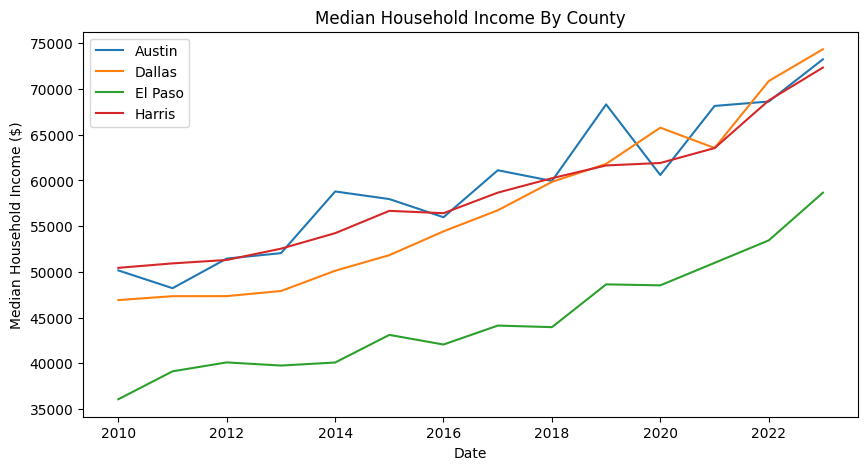

In [20]:
plt.figure(figsize=(10,5))

for name, group in final_api_df.groupby("County"):
    plt.plot(group["Date"], group["Med House Income"], label=name)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Median Household Income ($)")
plt.title("Median Household Income By County")
plt.savefig("plots/median_house_income_by_county.png", dpi=300, bbox_inches='tight')

plt.show()

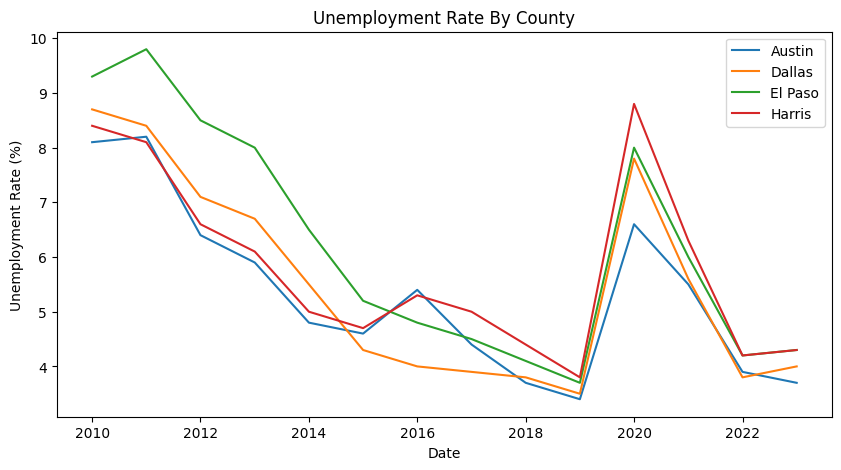

In [21]:
plt.figure(figsize=(10,5))

for name, group in final_api_df.groupby("County"):
    plt.plot(group["Date"], group["Unemployment Rate"], label=name)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate By County")
plt.savefig("plots/unemployment_rate_by_county.png", dpi=300, bbox_inches='tight')

plt.show()

In [22]:
steal_or_harris = steal_or_filtered[steal_or_filtered['County'] == 'Harris']
steal_or_dallas = steal_or_filtered[steal_or_filtered['County'] == 'Dallas']
steal_or_el_paso = steal_or_filtered[steal_or_filtered['County'] == 'El Paso']
steal_or_austin = steal_or_filtered[steal_or_filtered['County'] == 'Austin']

In [23]:
viol_or_harris = viol_or_filtered[viol_or_filtered['County'] == 'Harris']
viol_or_dallas = viol_or_filtered[viol_or_filtered['County'] == 'Dallas']
viol_or_el_paso = viol_or_filtered[viol_or_filtered['County'] == 'El Paso']
viol_or_austin = viol_or_filtered[viol_or_filtered['County'] == 'Austin']

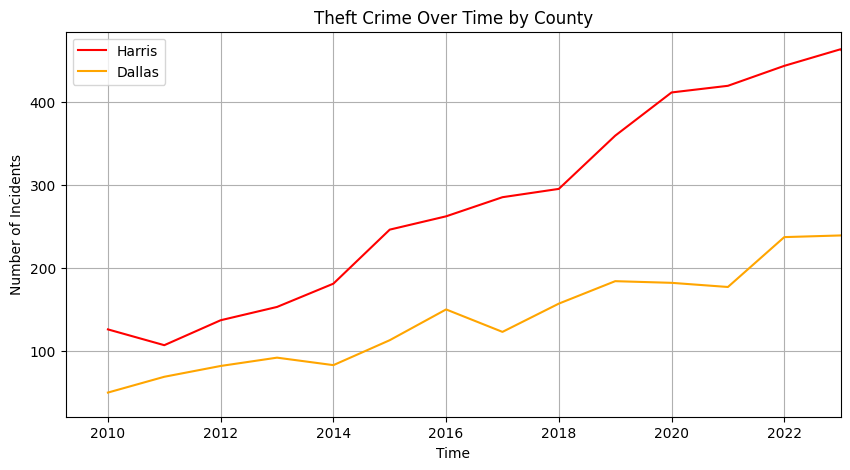

In [24]:
plt.figure(figsize=(10,5))

steal_harris_year_counts = steal_or_harris.groupby('Offense Date').size().reset_index(name='count')
steal_dallas_year_counts = steal_or_dallas.groupby('Offense Date').size().reset_index(name='count')

#plt.plot(final_api_df['Date'], final_api_df['Unemployment Rate'], label='Unemployment Rate')
plt.plot(steal_harris_year_counts['Offense Date'], steal_harris_year_counts['count'], label='Harris', color = 'Red')
plt.plot(steal_dallas_year_counts['Offense Date'], steal_dallas_year_counts['count'], label='Dallas', color = 'Orange')


plt.xlabel('Time')
plt.ylabel('Number of Incidents')
plt.title('Theft Crime Over Time by County')
plt.legend()
plt.grid(True)
plt.xlim(right=2023)
plt.savefig("plots/theft_crime_by_county_harris_dallas.png", dpi=300, bbox_inches='tight')

plt.show()

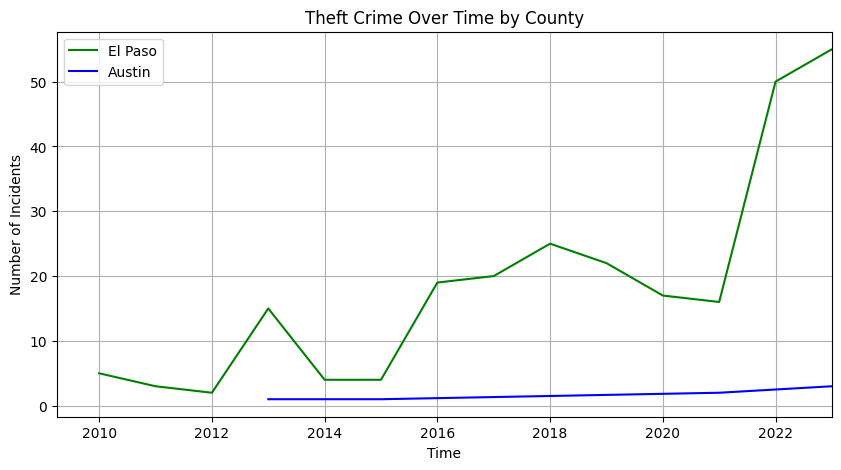

In [25]:
plt.figure(figsize=(10,5))

steal_el_paso_year_counts = steal_or_el_paso.groupby('Offense Date').size().reset_index(name='count')
steal_austin_year_counts = steal_or_austin.groupby('Offense Date').size().reset_index(name='count')

plt.plot(steal_el_paso_year_counts['Offense Date'], steal_el_paso_year_counts['count'], label='El Paso', color = 'Green')
plt.plot(steal_austin_year_counts['Offense Date'], steal_austin_year_counts['count'], label='Austin', color = 'Blue')


plt.xlabel('Time')
plt.ylabel('Number of Incidents')
plt.title('Theft Crime Over Time by County')
plt.legend()
plt.grid(True)
plt.xlim(right=2023)
plt.savefig("plots/theft_crime_by_county_elpaso_austin.png", dpi=300, bbox_inches='tight')

plt.show()

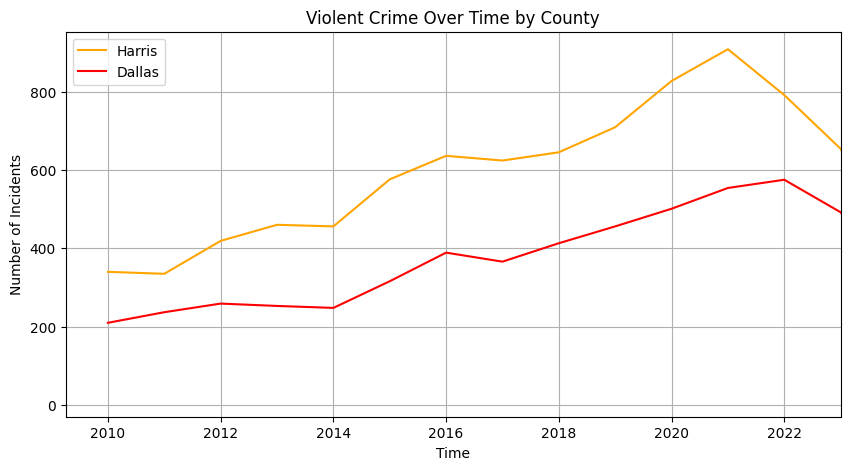

In [26]:
plt.figure(figsize=(10,5))

viol_harris_year_counts = viol_or_harris.groupby('Offense Date').size().reset_index(name='count')
viol_dallas_year_counts = viol_or_dallas.groupby('Offense Date').size().reset_index(name='count')

#plt.plot(final_api_df['Date'], final_api_df['Unemployment Rate'], label='Unemployment Rate')
plt.plot(viol_harris_year_counts['Offense Date'], viol_harris_year_counts['count'], label='Harris', color = 'Orange')
plt.plot(viol_dallas_year_counts['Offense Date'], viol_dallas_year_counts['count'], label='Dallas', color = 'Red')


plt.xlabel('Time')
plt.ylabel('Number of Incidents')
plt.title('Violent Crime Over Time by County')
plt.legend()
plt.grid(True)
plt.xlim(right=2023)
plt.savefig("plots/violent_crime_by_county_harris_dallas.png", dpi=300, bbox_inches='tight')

plt.show()

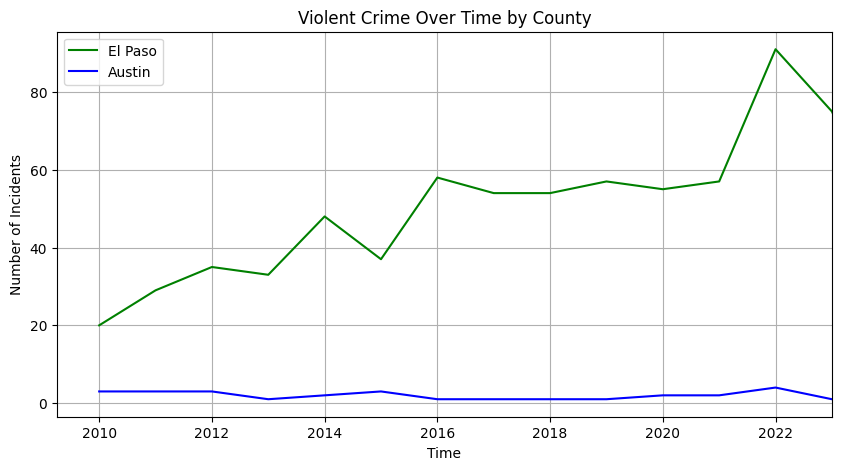

In [27]:
plt.figure(figsize=(10,5))

viol_el_paso_year_counts = viol_or_el_paso.groupby('Offense Date').size().reset_index(name='count')
viol_austin_year_counts = viol_or_austin.groupby('Offense Date').size().reset_index(name='count')

plt.plot(viol_el_paso_year_counts['Offense Date'], viol_el_paso_year_counts['count'], label='El Paso', color = 'Green')
plt.plot(viol_austin_year_counts['Offense Date'], viol_austin_year_counts['count'], label='Austin', color = 'Blue')


plt.xlabel('Time')
plt.ylabel('Number of Incidents')
plt.title('Violent Crime Over Time by County')
plt.legend()
plt.grid(True)
plt.xlim(right=2023)
plt.savefig("plots/violent_crime_by_county_elpaso_austin.png", dpi=300, bbox_inches='tight')

plt.show()